# Ejemplo de construcción y uso del gramiano de alcanzabilidad para un sistema LTI

Para un sistema LTI (un par $A,B$) el gramiano de alcanzabilidad se define como,

$$W_R[t_1,0] = \int_0^{t_1} e^{At}BB^Te^{A^Tt}\,dt$$

donde por razones (espero) conocidas estamos tomando directamente $t_0 = 0$.

Podemos definir una función en Python que calcule el integrando $e^{At}BB^Te^{A^Tt}$ para cualquier valor de $t$ e integrarla numéricamente.

In [2]:
import numpy as np
import control as ct
from scipy.linalg import expm
from scipy.integrate import quad_vec, solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

Vamos a ver cómo hacerlo con el mismo par $(A,B)$ de ejemplo que en el gramiano de controlabilidad,

$$\dot{x} = \begin{pmatrix}1&2&3 \\ 2&-2&1 \\ 1&4&-6\end{pmatrix} x + \begin{pmatrix}1 \\ -1 \\ 2\end{pmatrix} u$$

In [3]:
A = np.array([[1, 2, 3], [2, -2, 1], [1, 4, -6]])
B = np.array([[1], [-1], [2]])

C_rank = np.linalg.matrix_rank(ct.ctrb(A, B))
la = np.linalg.eigvals(A)
print('rank(ctrb(A,B)) =', C_rank)
print('eig(A) =', la)

rank(ctrb(A,B)) = 3
eig(A) = [ 2.9176 -3.3297 -6.5879]


El rango de la matriz de controlabilidad es 3, por tanto, el sistema es controlable. Sin embargo, la matriz $A$ tiene un autovalor con parte real positiva, por tanto no es una matriz de estabilidad (Hurwitz). El sistema no es estable.

Supongamos que queremos obtener $W_R[0.1,0]$ (elijo un tiempo tan corto porque, al ser un sistema inestable, diverge muy rápido; prueba con otros sistemas estables y verás que se comporta mejor).

In [4]:
def dgramr(t, t1, A, B):
    """
    Integrando del gramiano de alcanzabilidad para un par (A,B) y un
    tiempo final t1, tiempo inicial t0=0.
    """
    return expm(A*(t1 - t)) @ B @ B.T @ expm(A.T*(t1 - t))

t1 = 0.1

Igual que antes, integramos con `scipy.integrate.quad_vec` (equivalente a `integral(f,t0,t1,'ArrayValued',1)` de MATLAB).

In [5]:
wr10_0, err = quad_vec(lambda t: dgramr(t, t1, A, B), 0, t1)
wr10_0

array([[ 0.1488, -0.0862,  0.1689],
       [-0.0862,  0.0548, -0.1073],
       [ 0.1689, -0.1073,  0.2099]])

Y también podemos verificar con el mismo buclecito "a lo burro" que usamos en el gramiano de controlabilidad.

In [6]:
dt = 0.00001  # paso de integracion
t = np.arange(0, t1 + dt, dt)

WR10_0 = np.zeros((3, 3))
for ti in t:
    WR10_0 = WR10_0 + dgramr(ti, t1, A, B) * dt

diferencia = wr10_0 - WR10_0
print('WR10_0 =\n', WR10_0)
with np.printoptions(precision=17, suppress=False):
    print('diferencia =\n', diferencia)

WR10_0 =
 [[ 0.1488 -0.0862  0.1689]
 [-0.0862  0.0548 -0.1073]
 [ 0.1689 -0.1073  0.2099]]
diferencia =
 [[-1.4829671036858949e-05  8.2975298205389958e-06 -1.6872723104077725e-05]
 [ 8.2975298205389958e-06 -6.1062973212219762e-06  1.2305757147848539e-05]
 [-1.6872723104077725e-05  1.2305757147848539e-05 -2.4805681122314072e-05]]


La diferencia es del orden del paso de integración elegido para el segundo método.

Supongamos ahora que queremos en 0.1 segundos alcanzar el estado

$$x_1 = \begin{pmatrix}1\\ 1 \\ -1\end{pmatrix}$$

Como el sistema es controlable, $x_1\in \text{Im}\{W_R[0, t_1]\} \Rightarrow \eta_1 = W_R[0,t_1]^{-1}x_1$.

In [7]:
x1 = np.array([1, 1, -1])
eta1 = np.linalg.inv(WR10_0) @ x1
eta1

array([  -95.6422, 33989.132 , 17442.74  ])

Ahora sabemos que para llevar nuestro sistema en tiempo $t_1$ a $x_1$ debemos emplear una entrada:

$$u(t)=B^T\Phi(0,t_1)^T\eta_1=B^Te^{A^T(t_1-t)} \eta_1$$

Así que creamos una función para $u(t)$.

In [8]:
def U(t, t1, A, B, eta):
    """
    Entrada de control de minima energia que lleva un sistema LTI de
    x0 = 0 a x1. eta debe obtenerse a partir de x1, calculando e
    invirtiendo el gramiano de alcanzabilidad.
    """
    return B.T @ expm(A.T*(t1 - t)) @ eta

Ahora deberíamos integrar nuestro sistema lineal a ver qué pasa. Podemos hacerlo de varias maneras:

**1. Emplear `solve_ivp`.** Para ello, tenemos que crear como siempre una función con el sistema lineal.

In [9]:
def sistema_lineal(t, x, u, A, B):
    """Sistema lineal con entrada u(t) dada como funcion del tiempo."""
    return A @ x + B.flatten() * u(t)

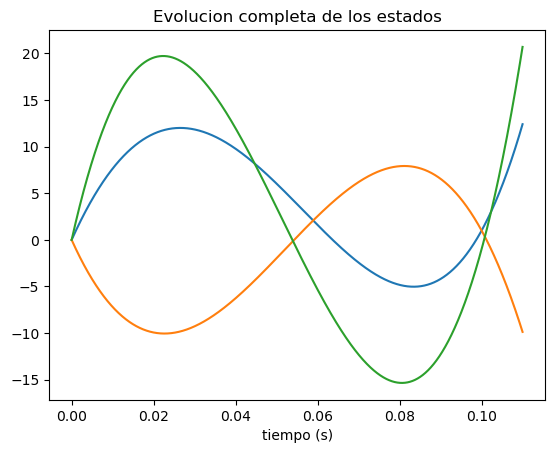

In [10]:
x0 = [0, 0, 0]

sol = solve_ivp(
    sistema_lineal, [0, t1 + 0.01], x0,
    args=(lambda t: U(t, t1, A, B, eta1), A, B),
    max_step=1e-5
)

plt.figure(1)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.title('Evolucion completa de los estados')
plt.show()

Hacemos zoom en torno a 0.1 para comprobar que, efectivamente, en ese punto se han alcanzado los valores deseados ($x_1=(1,1,-1)$).

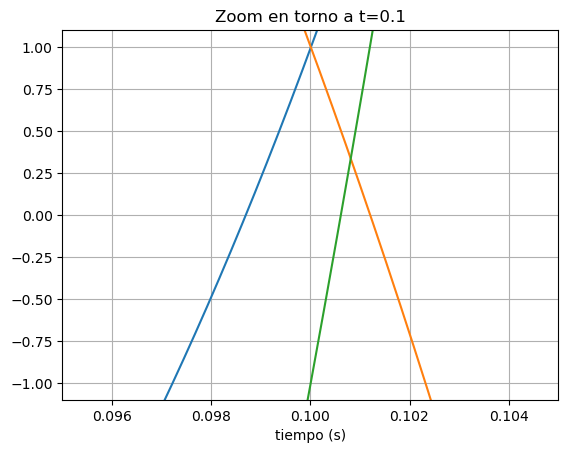

In [11]:
plt.figure(2)
plt.plot(sol.t, sol.y.T)
plt.xlim([0.095, 0.105])
plt.ylim([-1.1, 1.1])
plt.grid(True)
plt.xlabel('tiempo (s)')
plt.title('Zoom en torno a t=0.1')
plt.show()

**2. Los sistemas lineales en `control` admiten una construcción especial.** Podemos emplearla, pero hay que definir las 4 matrices $A,B,C,D$ típicas de cualquier sistema lineal.

In [12]:
C = np.eye(3)   # consideramos todos los estados como salidas del sistema
D = np.zeros((3, 1))
sys = ct.ss(A, B, C, D)
sys

StateSpace(array([[ 1.,  2.,  3.],
       [ 2., -2.,  1.],
       [ 1.,  4., -6.]]), array([[ 1.],
       [-1.],
       [ 2.]]), array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), array([[0.],
       [0.],
       [0.]]))

Para poder simular la entrada debemos calcularla específicamente para un array de tiempos.

In [13]:
t = np.arange(0, t1 + 0.001, 0.001)
Ut = np.array([U(ti, t1, A, B, eta1) for ti in t]).flatten()
Ut.shape

(101,)

Empleamos `control.forced_response` (equivalente a `lsim`), dando la condición inicial $x_0=0$.

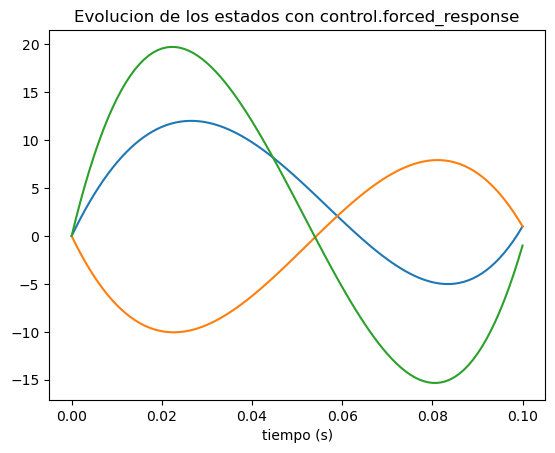

In [14]:
resp = ct.forced_response(sys, T=t, U=Ut, X0=[0, 0, 0])

plt.figure(3)
plt.plot(resp.time, resp.states.T)
plt.xlabel('tiempo (s)')
plt.title('Evolucion de los estados con control.forced_response')
plt.show()

## Notas finales

Es interesante observar que, mientras que el gramiano de alcanzabilidad nos proporciona un sistema para calcular una entrada $u$ que lleve el sistema a cualquier punto del espacio de estados, la matriz de controlabilidad no lo permite directamente, ni siquiera en este caso en el que la matriz de controlabilidad es invertible.